In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import os
import sys
import cv2

sys.path.append(r"C:\Users\sjefs\Desktop\Uni\Speciale\Kode\library")
import CV_functions as CV_func
import CV_classes as CV_class
from PIL import Image
from PIL.TiffTags import TAGS
import matplotlib.pyplot as plt
import random

from ipywidgets import interact, IntSlider
from matplotlib.pyplot import gray

# Loading a run

In [39]:
path_to_folder = r"C:\Users\sjefs\Desktop\Uni\Speciale\Data\SharangGarudTopBP1data_processed\TopBP1_zproj"
run_number = "10_2"


N_images = 25

# Loading chromosome data
Image_array_1 = CV_func.load_time_series(1, run_number, path_to_folder)
Image_array_2 = CV_func.load_time_series(2, run_number, path_to_folder)


# Testing methods

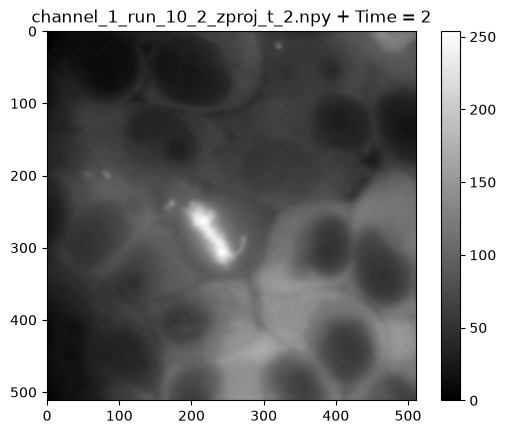

In [54]:
# We load and threshold a sample image
test_image = Image_array_1[2]
test_image.blur(ksize = (5,5), sigma = 1.4)
test_image.normalize()
C = -int(test_image.average() * 0.3)
test_image.adaptive_threshold(block_size=101, C=C)
test_image.display()
binary = test_image.th
test_array = test_image.array

# Watershed segmentation
Seems to work best for segmenting overlapping objects in an image.

It acts on the thresholded binary image to separate overlapping objects.

Detected 7 object(s)


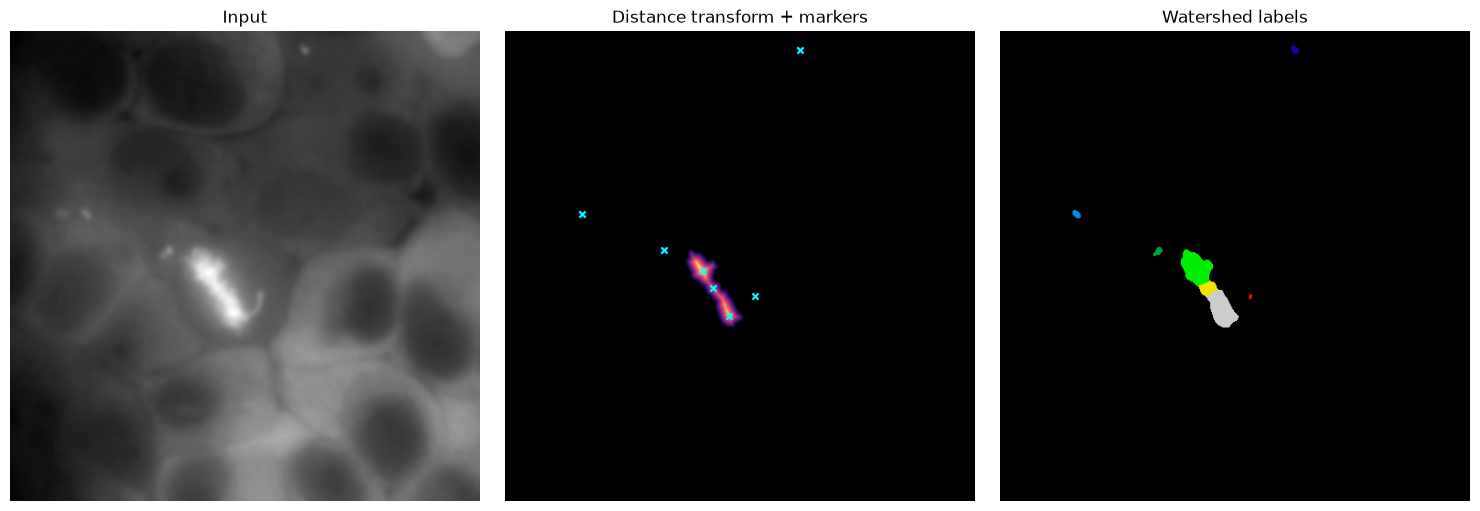

In [53]:
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed


# Clean up noise and close small gaps
kernel = np.ones((3, 3), np.uint8)
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

# Distance transform: peaks represent object centers, used to split touching objects
distance = ndi.distance_transform_edt(opened)
coords = peak_local_max(distance, min_distance=10, labels=opened)
markers_mask = np.zeros(distance.shape, dtype=bool)
markers_mask[tuple(coords.T)] = True
markers, n_markers = ndi.label(markers_mask)

# Watershed on the negative distance transform (basins grow from the markers)
labels = watershed(-distance, markers, mask=opened)
n_objects = labels.max()
print(f"Detected {n_objects} object(s)")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(test_array, cmap="gray")
axes[0].set_title("Input")
axes[1].imshow(distance, cmap="magma")
axes[1].scatter(coords[:, 1], coords[:, 0], c="cyan", s=20, marker="x")
axes[1].set_title("Distance transform + markers")
axes[2].imshow(labels, cmap="nipy_spectral")
axes[2].set_title("Watershed labels")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


# Multiple image run

# Channel 1


In [55]:
#### Updated version

C_factor = 0.3
method = cv2.ADAPTIVE_THRESH_GAUSSIAN_C

# Setup some arrays for storing results
center_of_mass_array = np.zeros((N_images, 2))
area_array = np.zeros(N_images)
largest_segment_array = np.zeros(N_images, dtype = object)
all_segments = []
spread_array = np.zeros((N_images, 2))
threshold_array = []

# Måske tilføj rotation som statistik


# Full image processing for each image
for i in range(N_images):
    # Load image and preprocess
    Image = Image_array_1[i]
    Image.blur(ksize=(5, 5), sigma=1.4)
    Image.normalize()

    # Adaptive thresholding. Fixing to image average
    average = Image.average()
    C = -int(average*C_factor)
    th = Image.adaptive_threshold(block_size=101, C=C, method = method)


    # Segmenting the image using region growing
    marked_points = CV_func.get_marked_points(th)
    segments = CV_func.region_growing(th, marked_points, min_size=10)
    largest_segment = CV_func.get_largest_segment(segments)

    # Storing some values
    all_segments.append(segments)
    largest_segment_array[i] = largest_segment
    threshold_array.append(th)

    # Calculating some statistics
    center_of_mass = CV_func.get_center_of_mass(largest_segment)
    area = CV_func.get_area(largest_segment)
    spread = CV_func.get_spread(largest_segment)

    # Storing the calculated statistics
    center_of_mass_array[i] = center_of_mass
    area_array[i] = area
    spread_array[i] = spread


def plot_frame(i):
    Image = Image_array_1[i]

    fig = plt.figure(figsize=(6, 6))
    plt.imshow(Image.array_original, cmap="gray")

    for segment in all_segments[i]:
        CV_func.plot_segment(segment)

    com = center_of_mass_array[i]
    plt.plot(com[0], com[1], "rx", markersize=12, markeredgewidth=3)

    plt.title(f"Image {i}")
    plt.axis("off")
    plt.show()
    plt.close(fig)


interact(
    plot_frame,
    i=IntSlider(min=0, max=N_images - 1, step=1, value=0),
)

interactive(children=(IntSlider(value=0, description='i', max=24), Output()), _dom_classes=('widget-interact',…

<function __main__.plot_frame(i)>

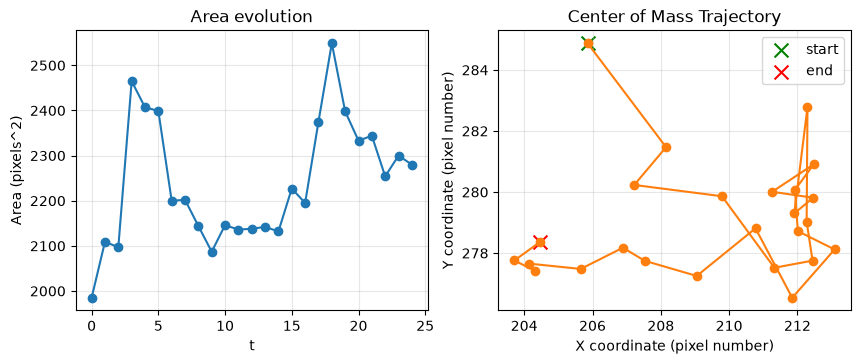

In [28]:
plt.figure(figsize =(10, 8))
plt.subplot(2, 2, 1)
plt.plot(np.arange(N_images), area_array, marker="o", color="tab:blue")
plt.xlabel("t")
plt.ylabel("Area (pixels^2)")
plt.title("Area evolution")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
# plot trajectory of the center of mass, marking the start point
plt.plot(
    [com[0] for com in center_of_mass_array],
    [com[1] for com in center_of_mass_array],
    marker="o",
    color="tab:orange"
)
plt.scatter(center_of_mass_array[0][0], center_of_mass_array[0][1], color="green", marker="x", s=100, label = "start")
plt.scatter(center_of_mass_array[-1][0], center_of_mass_array[-1][1], color="red", marker="x", s=100, label = "end")
plt.xlabel("X coordinate (pixel number)")
plt.ylabel("Y coordinate (pixel number)")
plt.title("Center of Mass Trajectory")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Channel 1 Statistics.png")

#plt.subplot(2, 2, 3)
#plt.plot(np.arange(N_images), spread_array[:, 0], marker="o", color="tab:green", label="X spread")
#plt.plot(np.arange(N_images), spread_array[:, 1], marker="o", color="tab:red", label="Y spread")
#plt.xlabel("Frame")
#plt.ylabel("Spread (pixels)")
#plt.title("Spread evolution")
#plt.legend()
#plt.grid(True, alpha=0.3)

# Channel 2

In [ ]:

C_factor = 0.10
scale = 1
all_segments_2 = []
for i in range(N_images):
    Image = Image_array_2[i]
    Image.normalize()

    cropped_image = CV_func.get_bounding_box(Image.array_original, largest_segment_array[i], scale=scale)
    Image.array = cropped_image

    average = Image.average()
    C = -int(average*C_factor)

    th = Image.adaptive_threshold(block_size=51, C=C)

    marked_points = CV_func.get_marked_points(th)
    segments = CV_func.region_growing(th, marked_points, min_size=1)
    all_segments_2.append(segments)

    def plot_frame(i):
        Image = Image_array_2[i]
        Image.normalize()
        cropped_image = CV_func.get_bounding_box(Image.array_original, largest_segment_array[i], scale=scale)
        Image.array = cropped_image
        plt.figure(figsize=(6, 6))
        plt.imshow(Image.array, cmap='gray')
        for segment in all_segments_2[i]:
            CV_func.plot_segment(segment)



        plt.title(f"Image {i}")
        plt.axis("off")
        plt.show()
        plt.close()

interact(plot_frame, i=IntSlider(min=0, max=N_images-1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='i', max=24), Output()), _dom_classes=('widget-interact',…

<function __main__.plot_frame(i)>

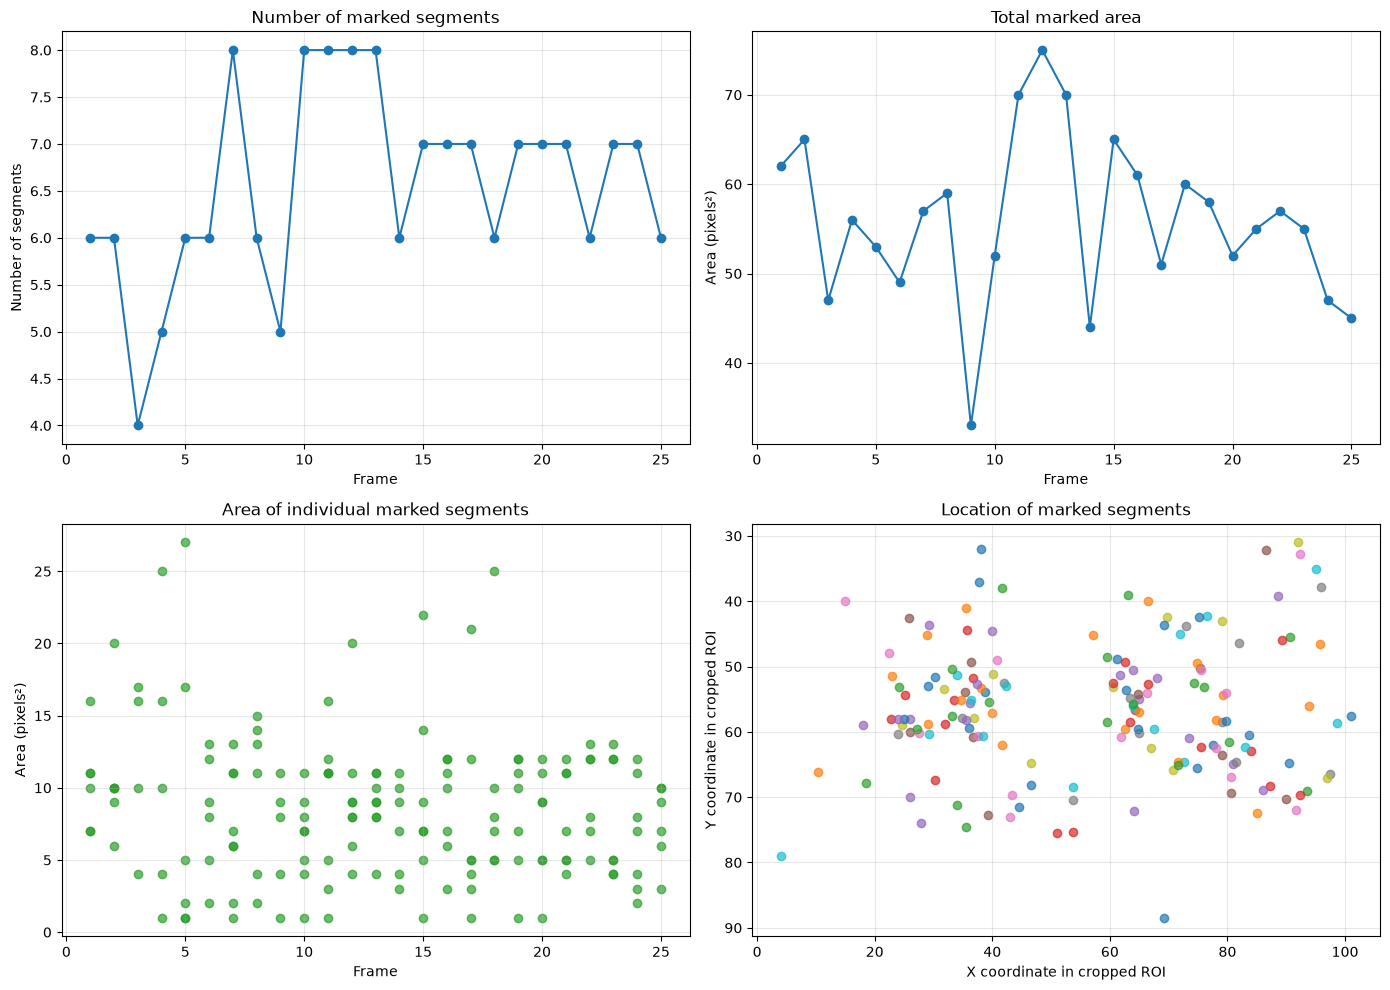

Frame 1:
  Segment 1: area=7 pixels², center=(38.00, 32.00)
  Segment 2: area=11 pixels², center=(37.73, 37.00)
  Segment 3: area=7 pixels², center=(61.29, 48.86)
  Segment 4: area=16 pixels², center=(77.50, 62.00)
  Segment 5: area=10 pixels², center=(90.50, 64.80)
  Segment 6: area=11 pixels², center=(69.18, 88.45)
Frame 2:
  Segment 1: area=10 pixels², center=(35.60, 41.10)
  Segment 2: area=9 pixels², center=(28.89, 45.22)
  Segment 3: area=6 pixels², center=(57.17, 45.17)
  Segment 4: area=20 pixels², center=(79.25, 54.30)
  Segment 5: area=10 pixels², center=(93.80, 56.00)
  Segment 6: area=10 pixels², center=(85.00, 72.50)
Frame 3:
  Segment 1: area=16 pixels², center=(41.69, 37.94)
  Segment 2: area=4 pixels², center=(59.50, 48.50)
  Segment 3: area=17 pixels², center=(80.29, 61.59)
  Segment 4: area=10 pixels², center=(93.50, 69.00)
Frame 4:
  Segment 1: area=25 pixels², center=(35.68, 44.44)
  Segment 2: area=4 pixels², center=(62.50, 49.25)
  Segment 3: area=1 pixels², cente

In [25]:
# Channel 2 statistics: area and location of every marked segment
segment_counts_2 = np.zeros(N_images, dtype=int)
total_area_2 = np.zeros(N_images, dtype=int)
segment_areas_2 = []
segment_centers_2 = []

for frame, frame_segments in enumerate(all_segments_2):
    areas = []
    centers = []

    for segment in frame_segments:
        points = np.asarray(segment)

        if points.size == 0:
            continue

        areas.append(len(segment))
        centers.append(points.mean(axis=0))  # (x, y)

    segment_counts_2[frame] = len(areas)
    total_area_2[frame] = sum(areas)
    segment_areas_2.append(areas)
    segment_centers_2.append(centers)

# Statistics page
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

frames = np.arange(1, N_images + 1)

axes[0, 0].plot(frames, segment_counts_2, marker="o")
axes[0, 0].set_title("Number of marked segments")
axes[0, 0].set_xlabel("Frame")
axes[0, 0].set_ylabel("Number of segments")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(frames, total_area_2, marker="o", color="tab:blue")
axes[0, 1].set_title("Total marked area")
axes[0, 1].set_xlabel("Frame")
axes[0, 1].set_ylabel("Area (pixels²)")
axes[0, 1].grid(alpha=0.3)

# Area of each segment in every frame
for frame, areas in enumerate(segment_areas_2, start=1):
    axes[1, 0].scatter(
        [frame] * len(areas),
        areas,
        color="tab:green",
        alpha=0.7
    )

axes[1, 0].set_title("Area of individual marked segments")
axes[1, 0].set_xlabel("Frame")
axes[1, 0].set_ylabel("Area (pixels²)")
axes[1, 0].grid(alpha=0.3)

# Location of every segment in cropped-image coordinates
for frame, centers in enumerate(segment_centers_2, start=1):
    if centers:
        centers = np.asarray(centers)
        axes[1, 1].scatter(
            centers[:, 0],
            centers[:, 1],
            label=f"Frame {frame}",
            alpha=0.7
        )

axes[1, 1].set_title("Location of marked segments")
axes[1, 1].set_xlabel("X coordinate in cropped ROI")
axes[1, 1].set_ylabel("Y coordinate in cropped ROI")
axes[1, 1].invert_yaxis()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Channel 2 Statistics.png")
plt.show()

# Print per-frame segment statistics
for frame in range(N_images):
    print(f"Frame {frame + 1}:")
    for number, (area_value, center_value) in enumerate(
        zip(segment_areas_2[frame], segment_centers_2[frame]),
        start=1
    ):
        print(
            f"  Segment {number}: "
            f"area={area_value} pixels², "
            f"center=({center_value[0]:.2f}, {center_value[1]:.2f})"
        )